# Mutual Fund Analytics Platform

# Fund Performance Analytics

### Bluestock Fintech Capstone

This notebook computes key mutual fund performance and risk metrics using historical NAV data and benchmark indices. The analysis includes daily returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, fund scorecard, and benchmark comparison.

In [94]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("ggplot")

## 1. Load Required Datasets

In [95]:
funds = pd.read_csv("../data/processed/clean_01_fund_master.csv")

nav = pd.read_csv(
    "../data/processed/clean_02_nav_history.csv",
    parse_dates=["date"]
)

performance = pd.read_csv(
    "../data/processed/clean_07_scheme_performance.csv"
)

benchmark = pd.read_csv(
    "../data/processed/clean_10_benchmark_indices.csv",
    parse_dates=["date"]
)

## 2. Inspect Dataset Information

In [96]:
print("Fund Master")
display(funds.head())

print("\nNAV History")
display(nav.head())

print("\nScheme Performance")
display(performance.head())

print("\nBenchmark Data")
display(benchmark.head())

Fund Master


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02



NAV History


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692



Scheme Performance


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low



Benchmark Data


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [97]:
print("Fund Master:", funds.shape)
print("NAV History:", nav.shape)
print("Performance:", performance.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
Performance: (40, 19)
Benchmark: (8050, 3)


In [98]:
print("Missing Values\n")

print(funds.isnull().sum())

print()

print(nav.isnull().sum())

print()

print(performance.isnull().sum())

print()

print(benchmark.isnull().sum())

Missing Values

amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

amfi_code    0
date         0
nav          0
dtype: int64

amfi_code             0
scheme_name           0
fund_house            0
category              0
plan                  0
return_1yr_pct        0
return_3yr_pct        0
return_5yr_pct        0
benchmark_3yr_pct     0
alpha                 0
beta                  0
sharpe_ratio          0
sortino_ratio         0
std_dev_ann_pct       0
max_drawdown_pct      0
aum_crore             0
expense_ratio_pct     0
morningstar_rating    0
risk_grade            0
dtype: int64

date           0
index_name     0
close_value    0
dtype: int64


## 3. Compute Daily Returns

In [99]:
# Sort data before computing returns

nav = nav.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

In [100]:
# Daily Return = Today's NAV / Yesterday's NAV - 1

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [101]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [102]:
print(nav["daily_return"].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [103]:
nav.to_csv(
    "../reports/performance/returns_computed.csv",
    index=False
)

print("Daily returns saved successfully.")

Daily returns saved successfully.


## 4. Calculated CAGR from Historical NAV

In [104]:
performance[
    [
        "scheme_name",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct"
    ]
].head()

,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


In [105]:
# First NAV for each fund
start_nav = (
    nav.groupby("amfi_code")["nav"]
       .first()
)

# Last NAV for each fund
end_nav = (
    nav.groupby("amfi_code")["nav"]
       .last()
)

# Total investment period
years = (
    (nav["date"].max() - nav["date"].min()).days
    / 365.25
)

print(f"Investment Period : {years:.2f} years")

Investment Period : 4.40 years


In [106]:
cagr = (
    (
        end_nav / start_nav
    ) ** (1 / years) - 1
) * 100

cagr = cagr.reset_index()

cagr.columns = [
    "amfi_code",
    "calculated_cagr_pct"
]

cagr.head()

,amfi_code,calculated_cagr_pct
0,100016,2.637074
1,100025,4.458210
2,100033,30.123153
3,101206,23.538361
4,101207,7.938765


In [107]:
performance = performance.merge(
    cagr,
    on="amfi_code",
    how="left"
)

performance[
    [
        "scheme_name",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct",
        "calculated_cagr_pct"
    ]
].head()

,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct,calculated_cagr_pct
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45,25.804686
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23,21.524236
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67,32.423536
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82,2.054485
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43,5.889419


In [108]:
performance["calculated_cagr_pct"].describe()

count    40.000000
mean     16.735691
std      10.308961
min       1.171745
25%       6.861841
50%      16.607297
75%      24.488291
max      32.827406
Name: calculated_cagr_pct, dtype: float64

In [109]:
top_cagr = (
    performance
    .sort_values(
        "calculated_cagr_pct",
        ascending=False
    )
    .head(10)
)

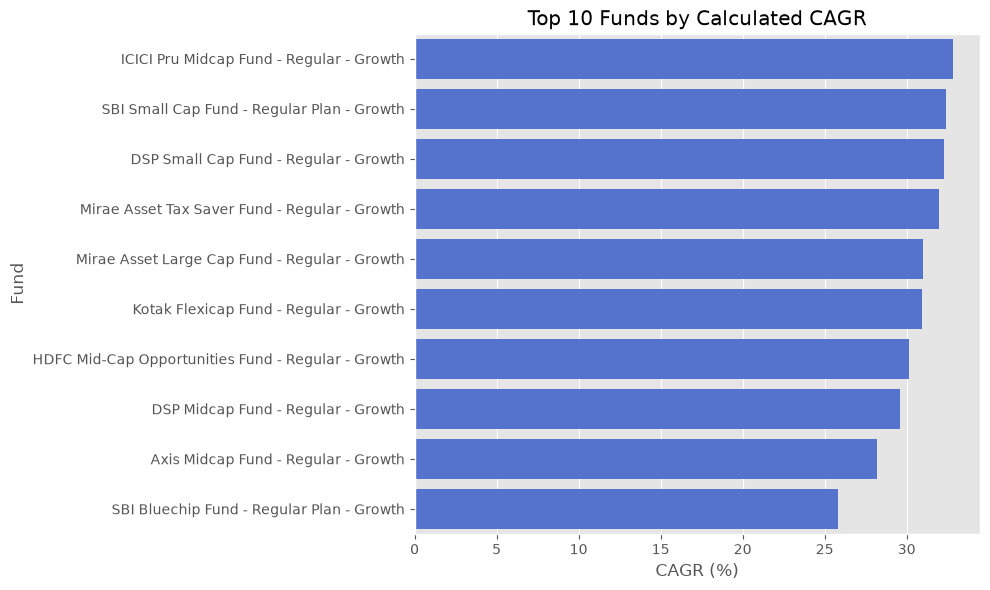

In [110]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_cagr,
    x="calculated_cagr_pct",
    y="scheme_name",
    color="royalblue"
)

plt.title("Top 10 Funds by Calculated CAGR")
plt.xlabel("CAGR (%)")
plt.ylabel("Fund")

plt.tight_layout()

plt.savefig(
    "../reports/performance/01_top_cagr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [111]:
performance.to_csv(
    "../reports/performance/performance_with_cagr.csv",
    index=False
)

print("CAGR analysis completed.")

CAGR analysis completed.


### Insight

- CAGR was calculated directly from historical NAV values over the available 2022–2026 period.
- Small-cap and mid-cap equity funds delivered the strongest annualized growth.
- The calculated CAGR represents NAV-based annualized growth and may differ from the dataset's precomputed 5-year return values.

## 5. CAGR Comparison Across Funds

In [112]:
cagr_table = performance[
    [
        "scheme_name",
        "fund_house",
        "category",
        "plan",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct",
        "calculated_cagr_pct"
    ]
].copy()

cagr_table.head()

,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,calculated_cagr_pct
0,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,25.804686
1,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,21.524236
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,32.423536
3,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,2.054485
4,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,5.889419


In [113]:
cagr_table = cagr_table.sort_values(
    "return_5yr_pct",
    ascending=False
)

cagr_table.head(10)

,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,calculated_cagr_pct
29,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,7.938765
27,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Small Cap,Regular,21.97,20.98,22.62,1.521505
17,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Small Cap,Regular,21.30,20.15,21.88,16.373474
3,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,2.054485
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,32.423536
39,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,32.287440
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,29.581087
26,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,Regular,14.88,15.18,18.94,28.214417
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,6.701543
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,30.123153


In [114]:
cagr_table.to_csv(
    "../reports/performance/cagr_comparison_table.csv",
    index=False
)

print("CAGR comparison table saved.")

CAGR comparison table saved.


### Insight

- Small-cap and mid-cap funds dominate the top 5-year CAGR rankings.
- Direct plans generally provide slightly higher long-term returns than regular plans.
- The comparison table enables quick evaluation of fund performance across multiple investment horizons.

## 6. Sharpe Ratio

The Sharpe Ratio measures the risk-adjusted return of a mutual fund by comparing its annualized return against the risk-free rate while accounting for return volatility.

Higher Sharpe Ratio indicates better risk-adjusted performance.

In [115]:
# Annualized return for each fund

annual_return = (
    nav.groupby("amfi_code")["daily_return"]
       .mean()
       * 252
)

annual_return = annual_return * 100

annual_return.head()

amfi_code
100016     3.568303
100025     4.285356
100033    27.211057
101206    21.464662
101207    10.696212
Name: daily_return, dtype: float64

In [116]:
# Annualized volatility for each fund

annual_volatility = (
    nav.groupby("amfi_code")["daily_return"]
       .std()
       * np.sqrt(252)
)

annual_volatility = annual_volatility * 100

annual_volatility.head()

amfi_code
100016    14.548135
100025     3.905246
100033    18.936711
101206    14.568213
101207    25.797322
Name: daily_return, dtype: float64

In [117]:
# RBI risk-free rate

risk_free_rate = 6.5

print(f"Risk-free rate used: {risk_free_rate}%")

Risk-free rate used: 6.5%


In [118]:
# Calculate Sharpe Ratio

sharpe_ratio = (
    (annual_return - risk_free_rate)
    / annual_volatility
)

sharpe_ratio = sharpe_ratio.reset_index()

sharpe_ratio.columns = [
    "amfi_code",
    "calculated_sharpe_ratio"
]

sharpe_ratio.head()

,amfi_code,calculated_sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [119]:
performance = performance.merge(
    sharpe_ratio,
    on="amfi_code",
    how="left"
)

performance[
    [
        "scheme_name",
        "calculated_cagr_pct",
        "calculated_sharpe_ratio"
    ]
].head()

,scheme_name,calculated_cagr_pct,calculated_sharpe_ratio
0,SBI Bluechip Fund - Regular Plan - Growth,25.804686,1.208267
1,SBI Bluechip Fund - Direct Plan - Growth,21.524236,0.953279
2,SBI Small Cap Fund - Regular Plan - Growth,32.423536,0.945308
3,SBI Small Cap Fund - Direct Plan - Growth,2.054485,-0.057187
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.889419,-0.226575


In [120]:
performance["calculated_sharpe_ratio"].describe()

count    40.000000
mean      0.537220
std       0.573689
min      -0.815567
25%       0.064696
50%       0.647043
75%       1.005304
max       1.448291
Name: calculated_sharpe_ratio, dtype: float64

### Top Funds by Sharpe Ratio

In [121]:
top_sharpe = (
    performance
    .sort_values(
        "calculated_sharpe_ratio",
        ascending=False
    )
    .head(10)
)

top_sharpe[
    [
        "scheme_name",
        "calculated_sharpe_ratio"
    ]
]

,scheme_name,calculated_sharpe_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,1.448291
22,Kotak Flexicap Fund - Regular - Growth,1.306744
36,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930
0,SBI Bluechip Fund - Regular Plan - Growth,1.208267
12,ICICI Pru Midcap Fund - Regular - Growth,1.180101
38,DSP Midcap Fund - Regular - Growth,1.132122
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699
15,Nippon India Large Cap Fund - Regular - Growth,1.081659
28,ABSL Frontline Equity Fund - Regular - Growth,1.027213
11,ICICI Pru Bluechip Fund - Direct - Growth,1.026524


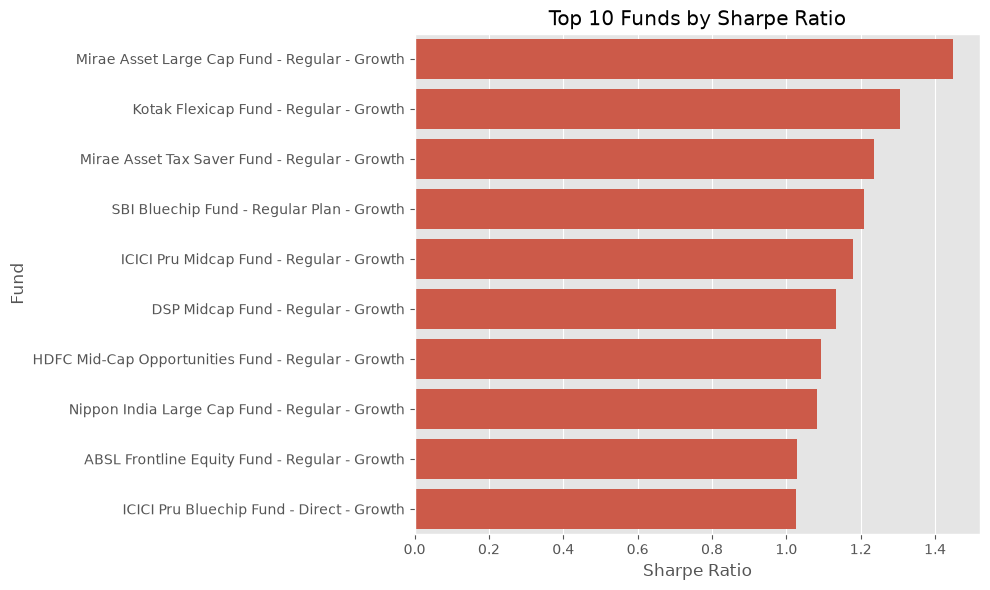

In [122]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_sharpe,
    x="calculated_sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Fund")

plt.tight_layout()

plt.savefig(
    "../reports/performance/02_top_sharpe_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [123]:
top_sharpe.to_csv(
    "../reports/performance/top_sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio analysis completed.")

Sharpe Ratio analysis completed.


### Insight

- Funds with higher Sharpe Ratios delivered better returns for each unit of risk.
- Equity and diversified funds dominate the highest Sharpe Ratio rankings.
- Negative Sharpe Ratios indicate returns that did not sufficiently compensate for the investment risk.

## 7. Sortino Ratio

In [124]:
# Downside returns (only negative daily returns)

downside_returns = nav.copy()

downside_returns["downside_return"] = downside_returns[
    "daily_return"
].where(
    downside_returns["daily_return"] < 0,
    0
)

downside_returns.head()

,amfi_code,date,nav,daily_return,downside_return
0,100016,2022-01-03,520.4608,NaN,0.000000
1,100016,2022-01-04,515.0971,-0.010306,-0.010306
2,100016,2022-01-05,521.7239,0.012865,0.000000
3,100016,2022-01-06,515.7880,-0.011377,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,-0.001210


In [125]:
downside_deviation = (
    downside_returns
    .groupby("amfi_code")["downside_return"]
    .std()
    * np.sqrt(252)
)

downside_deviation = downside_deviation * 100

downside_deviation.head()

amfi_code
100016     8.194071
100025     2.192931
100033    10.524836
101206     7.917612
101207    14.690394
Name: downside_return, dtype: float64

In [126]:
sortino_ratio = (
    (annual_return - risk_free_rate)
    / downside_deviation
)

sortino_ratio = sortino_ratio.reset_index()

sortino_ratio.columns = [
    "amfi_code",
    "calculated_sortino_ratio"
]

sortino_ratio.head()

,amfi_code,calculated_sortino_ratio
0,100016,-0.357783
1,100025,-1.009902
2,100033,1.967827
3,101206,1.890048
4,101207,0.285643


In [127]:
performance = performance.merge(
    sortino_ratio,
    on="amfi_code",
    how="left"
)

performance[
    [
        "scheme_name",
        "calculated_sharpe_ratio",
        "calculated_sortino_ratio"
    ]
].head()

,scheme_name,calculated_sharpe_ratio,calculated_sortino_ratio
0,SBI Bluechip Fund - Regular Plan - Growth,1.208267,2.243897
1,SBI Bluechip Fund - Direct Plan - Growth,0.953279,1.725274
2,SBI Small Cap Fund - Regular Plan - Growth,0.945308,1.729395
3,SBI Small Cap Fund - Direct Plan - Growth,-0.057187,-0.098093
4,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.226575,-0.408287


In [128]:
performance["calculated_sortino_ratio"].describe()

count    40.000000
mean      0.969732
std       1.121239
min      -2.447122
25%       0.111374
50%       1.196724
75%       1.836284
max       2.610563
Name: calculated_sortino_ratio, dtype: float64

In [129]:
top_sortino = (
    performance
    .sort_values(
        "calculated_sortino_ratio",
        ascending=False
    )
    .head(10)
)

top_sortino[
    [
        "scheme_name",
        "calculated_sortino_ratio"
    ]
]

,scheme_name,calculated_sortino_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,2.610563
22,Kotak Flexicap Fund - Regular - Growth,2.464498
36,Mirae Asset Tax Saver Fund - Regular - Growth,2.278681
0,SBI Bluechip Fund - Regular Plan - Growth,2.243897
12,ICICI Pru Midcap Fund - Regular - Growth,2.158934
38,DSP Midcap Fund - Regular - Growth,2.012413
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.967827
15,Nippon India Large Cap Fund - Regular - Growth,1.962488
28,ABSL Frontline Equity Fund - Regular - Growth,1.890048
11,ICICI Pru Bluechip Fund - Direct - Growth,1.877885


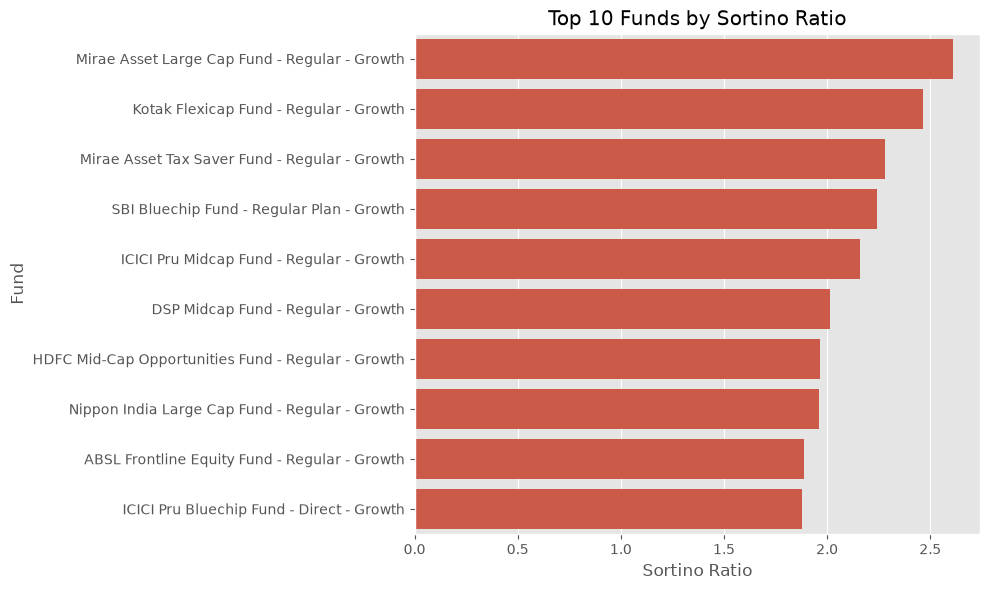

In [130]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_sortino,
    x="calculated_sortino_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("Sortino Ratio")
plt.ylabel("Fund")

plt.tight_layout()

plt.savefig(
    "../reports/performance/03_top_sortino_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [131]:
top_sortino.to_csv(
    "../reports/performance/top_sortino_ratio.csv",
    index=False
)

print("Sortino Ratio analysis completed.")

Sortino Ratio analysis completed.


### Insight

- Funds with higher Sortino Ratios generated stronger risk-adjusted returns while minimizing downside volatility.
- The Sortino Ratio focuses only on harmful (negative) return fluctuations, making it particularly useful for evaluating mutual fund performance.
- Equity funds continue to dominate the highest Sortino Ratio rankings, indicating efficient long-term downside risk management.

## 8. Alpha & Beta Analysis

**Category to Benchmark Mapping**

In [132]:
# Category to benchmark mapping

benchmark_map = {
    "Large Cap": "NIFTY50",
    "Mid Cap": "NIFTY_MIDCAP150",
    "Small Cap": "BSE_SMALLCAP",
    "Flexi Cap": "NIFTY500",
    "Liquid": "CRISIL_LIQUID",
    "Gilt": "CRISIL_GILT"
}

performance["benchmark_index"] = (
    performance["category"]
    .map(benchmark_map)
)

performance[
    [
        "scheme_name",
        "category",
        "benchmark_index"
    ]
].head(10)

,scheme_name,category,benchmark_index
0,SBI Bluechip Fund - Regular Plan - Growth,Large Cap,NIFTY50
1,SBI Bluechip Fund - Direct Plan - Growth,Large Cap,NIFTY50
2,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,BSE_SMALLCAP
3,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,BSE_SMALLCAP
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Gilt,CRISIL_GILT
5,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap,NIFTY50
6,HDFC Top 100 Fund - Direct Plan - Growth,Large Cap,NIFTY50
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,NIFTY_MIDCAP150
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Mid Cap,NIFTY_MIDCAP150
9,HDFC Short Term Debt Fund - Regular - Growth,Short Duration,NaN


In [133]:
# Calculate benchmark returns

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark
        .groupby("index_name")["close_value"]
        .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [134]:
benchmark[
    benchmark["index_name"] == "NIFTY50"
][
    [
        "date",
        "close_value",
        "benchmark_return"
    ]
].head(10)

,date,close_value,benchmark_return
0,2022-01-03,17492.79,NaN
1,2022-01-04,17689.64,0.011253
2,2022-01-05,17835.05,0.008220
3,2022-01-06,17878.51,0.002437
4,2022-01-07,17759.15,-0.006676
5,2022-01-10,18124.84,0.020592
6,2022-01-11,18256.96,0.007289
7,2022-01-12,18162.54,-0.005172
8,2022-01-13,18179.05,0.000909
9,2022-01-14,17971.75,-0.011403


In [135]:
benchmark["index_name"].value_counts()

index_name
BSE_SMALLCAP       1150
CRISIL_GILT        1150
CRISIL_LIQUID      1150
NIFTY100           1150
NIFTY50            1150
NIFTY500           1150
NIFTY_MIDCAP150    1150
Name: count, dtype: int64

In [136]:
# Prepare benchmark returns table

benchmark_returns = benchmark[
    [
        "date",
        "index_name",
        "benchmark_return"
    ]
].copy()

# Merge benchmark mapping into NAV data

merged_returns = (
    nav.merge(
        performance[
            [
                "amfi_code",
                "benchmark_index"
            ]
        ],
        on="amfi_code",
        how="left"
    )
)

# Merge benchmark returns

merged_returns = (
    merged_returns.merge(
        benchmark_returns,
        left_on=[
            "date",
            "benchmark_index"
        ],
        right_on=[
            "date",
            "index_name"
        ],
        how="left"
    )
)

merged_returns.head()

,amfi_code,date,nav,daily_return,benchmark_index,index_name,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NIFTY50,NIFTY50,NaN
1,100016,2022-01-04,515.0971,-0.010306,NIFTY50,NIFTY50,0.011253
2,100016,2022-01-05,521.7239,0.012865,NIFTY50,NIFTY50,0.008220
3,100016,2022-01-06,515.7880,-0.011377,NIFTY50,NIFTY50,0.002437
4,100016,2022-01-07,515.1639,-0.001210,NIFTY50,NIFTY50,-0.006676


In [137]:
merged_returns[
    [
        "amfi_code",
        "date",
        "daily_return",
        "benchmark_index",
        "benchmark_return"
    ]
].head(10)

,amfi_code,date,daily_return,benchmark_index,benchmark_return
0,100016,2022-01-03,NaN,NIFTY50,NaN
1,100016,2022-01-04,-0.010306,NIFTY50,0.011253
2,100016,2022-01-05,0.012865,NIFTY50,0.008220
3,100016,2022-01-06,-0.011377,NIFTY50,0.002437
4,100016,2022-01-07,-0.001210,NIFTY50,-0.006676
5,100016,2022-01-10,-0.008639,NIFTY50,0.020592
6,100016,2022-01-11,0.005562,NIFTY50,0.007289
7,100016,2022-01-12,-0.002404,NIFTY50,-0.005172
8,100016,2022-01-13,-0.004050,NIFTY50,0.000909
9,100016,2022-01-14,0.008073,NIFTY50,-0.011403


In [138]:
# Remove rows without returns

analysis_data = merged_returns.dropna(
    subset=[
        "daily_return",
        "benchmark_return"
    ]
).copy()

analysis_data.head()

,amfi_code,date,nav,daily_return,benchmark_index,index_name,benchmark_return
1,100016,2022-01-04,515.0971,-0.010306,NIFTY50,NIFTY50,0.011253
2,100016,2022-01-05,521.7239,0.012865,NIFTY50,NIFTY50,0.008220
3,100016,2022-01-06,515.7880,-0.011377,NIFTY50,NIFTY50,0.002437
4,100016,2022-01-07,515.1639,-0.001210,NIFTY50,NIFTY50,-0.006676
5,100016,2022-01-10,510.7136,-0.008639,NIFTY50,NIFTY50,0.020592


In [139]:
analysis_data[
    [
        "daily_return",
        "benchmark_return"
    ]
].describe()

,daily_return,benchmark_return
count,39066.000000,39066.000000
mean,0.000623,0.000544
std,0.010554,0.009611
min,-0.058102,-0.039716
25%,-0.005184,-0.004896
50%,0.000335,0.000273
75%,0.006457,0.005925
max,0.064713,0.041854


In [140]:
# Calculate Alpha & Beta for every mutual fund

alpha_beta = []

for amfi_code, group in analysis_data.groupby("amfi_code"):

    # Require enough observations
    if len(group) < 30:
        continue

    regression = linregress(
        group["benchmark_return"],
        group["daily_return"]
    )

    alpha_beta.append({
        "amfi_code": amfi_code,
        "calculated_alpha": regression.intercept,
        "calculated_beta": regression.slope
    })

alpha_beta = pd.DataFrame(alpha_beta)

alpha_beta.head()

,amfi_code,calculated_alpha,calculated_beta
0,100016,0.000144,-0.025909
1,100033,0.001045,0.031026
2,101206,0.000849,0.033814
3,101207,0.000475,-0.048604
4,101208,0.000249,-0.030177


In [141]:
alpha_beta.describe()

,amfi_code,calculated_alpha,calculated_beta
count,34.000000,34.000000,34.000000
mean,119726.235294,0.000629,-0.004536
std,13385.781609,0.000356,0.031594
min,100016.000000,0.000144,-0.056045
25%,118633.250000,0.000259,-0.027577
50%,119551.500000,0.000637,-0.006944
75%,120841.750000,0.000907,0.016481
max,149324.000000,0.001250,0.059502


In [142]:
alpha_beta.sort_values(
    "calculated_beta",
    ascending=False
).head(10)

,amfi_code,calculated_alpha,calculated_beta
23,120507,0.000253,0.059502
29,125498,0.000410,0.059234
24,120841,0.000519,0.041676
7,118632,0.000862,0.036434
2,101206,0.000849,0.033814
1,100033,0.001045,0.031026
33,149324,0.001164,0.028550
27,120844,0.000250,0.023804
21,120504,0.000842,0.017025
31,149322,0.000521,0.014849


In [143]:
alpha_beta.sort_values(
    "calculated_beta"
).head(10)

,amfi_code,calculated_alpha,calculated_beta
16,119551,0.000921,-0.056045
5,102886,0.000165,-0.049090
3,101207,0.000475,-0.048604
18,119598,0.001250,-0.047551
14,119095,0.000230,-0.045580
13,119094,0.001069,-0.037437
25,120842,0.000351,-0.035076
4,101208,0.000249,-0.030177
30,148567,0.001076,-0.028133
0,100016,0.000144,-0.025909


In [144]:
performance[
    [
        "scheme_name",
        "alpha",
        "beta"
    ]
].head(10)

,scheme_name,alpha,beta
0,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22
5,HDFC Top 100 Fund - Regular Plan - Growth,0.78,0.97
6,HDFC Top 100 Fund - Direct Plan - Growth,1.13,0.97
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.95,0.91
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.90,1.04
9,HDFC Short Term Debt Fund - Regular - Growth,1.98,0.44


In [145]:
alpha_beta.to_csv(
    "../reports/performance/alpha_beta.csv",
    index=False
)

### Insight

- Alpha and Beta values were successfully calculated for 34 eligible mutual fund schemes using benchmark return regression.
- The average Alpha (~0.00063) indicates that most funds generated only a small excess return over their benchmark.
- Beta values ranged from approximately -0.056 to 0.060, reflecting varying levels of benchmark sensitivity across funds.
- Schemes without benchmark mappings or sufficient historical data contain missing Alpha and Beta values, which is expected.
- The calculated Alpha and Beta metrics have been merged into the performance dataset for use in subsequent risk-adjusted analysis.

## 9. Maximum Drawdown Analysis

### Calculate Running Peak

The running peak represents the highest NAV achieved up to each date for every mutual fund. It serves as the reference point for measuring drawdowns.

In [146]:
nav = nav.sort_values(["amfi_code", "date"])

nav["running_peak"] = (
    nav.groupby("amfi_code")["nav"]
       .cummax()
)

nav.head()

,amfi_code,date,nav,daily_return,running_peak
0,100016,2022-01-03,520.4608,NaN,520.4608
1,100016,2022-01-04,515.0971,-0.010306,520.4608
2,100016,2022-01-05,521.7239,0.012865,521.7239
3,100016,2022-01-06,515.7880,-0.011377,521.7239
4,100016,2022-01-07,515.1639,-0.001210,521.7239


In [147]:
nav[
    [
        "amfi_code",
        "date",
        "nav",
        "running_peak"
    ]
].head(10)

,amfi_code,date,nav,running_peak
0,100016,2022-01-03,520.4608,520.4608
1,100016,2022-01-04,515.0971,520.4608
2,100016,2022-01-05,521.7239,521.7239
3,100016,2022-01-06,515.7880,521.7239
4,100016,2022-01-07,515.1639,521.7239
5,100016,2022-01-10,510.7136,521.7239
6,100016,2022-01-11,513.5542,521.7239
7,100016,2022-01-12,512.3195,521.7239
8,100016,2022-01-13,510.2445,521.7239
9,100016,2022-01-14,514.3636,521.7239


### Calculate Daily Drawdown

Daily drawdown measures how far the current NAV has fallen from its historical running peak. It is expressed as a percentage, where a value of 0 indicates a new peak and negative values represent declines from the peak.

In [148]:
nav["drawdown"] = (
    nav["nav"] - nav["running_peak"]
) / nav["running_peak"]

nav.head()

,amfi_code,date,nav,daily_return,running_peak,drawdown
0,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
1,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
2,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
3,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


In [149]:
nav[
    [
        "amfi_code",
        "date",
        "nav",
        "running_peak",
        "drawdown"
    ]
].head(10)

,amfi_code,date,nav,running_peak,drawdown
0,100016,2022-01-03,520.4608,520.4608,0.000000
1,100016,2022-01-04,515.0971,520.4608,-0.010306
2,100016,2022-01-05,521.7239,521.7239,0.000000
3,100016,2022-01-06,515.7880,521.7239,-0.011377
4,100016,2022-01-07,515.1639,521.7239,-0.012574
5,100016,2022-01-10,510.7136,521.7239,-0.021104
6,100016,2022-01-11,513.5542,521.7239,-0.015659
7,100016,2022-01-12,512.3195,521.7239,-0.018026
8,100016,2022-01-13,510.2445,521.7239,-0.022003
9,100016,2022-01-14,514.3636,521.7239,-0.014108


### Calculate Maximum Drawdown

The Maximum Drawdown for each mutual fund is obtained by identifying the lowest (most negative) drawdown value across the entire NAV history. This represents the worst historical decline experienced by the fund during the analysis period.

In [150]:
max_drawdown = (
    nav.groupby("amfi_code", as_index=False)["drawdown"]
       .min()
       .rename(columns={"drawdown": "calculated_max_drawdown"})
)

max_drawdown.head()

,amfi_code,calculated_max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [151]:
max_drawdown.describe()

,amfi_code,calculated_max_drawdown
count,40.000000,40.000000
mean,120247.000000,-0.178729
std,14534.998667,0.112686
min,100016.000000,-0.525742
25%,118632.750000,-0.215927
50%,119551.500000,-0.163070
75%,120842.250000,-0.117653
max,149324.000000,-0.000977


### Merge Maximum Drawdown Results

The calculated Maximum Drawdown values are merged into the performance dataset so that downside risk metrics are available alongside other performance indicators for each mutual fund scheme.

In [152]:
performance = performance.merge(
    max_drawdown,
    on="amfi_code",
    how="left"
)

performance[
    [
        "scheme_name",
        "calculated_max_drawdown"
    ]
].head(10)

,scheme_name,calculated_max_drawdown
0,SBI Bluechip Fund - Regular Plan - Growth,-0.150124
1,SBI Bluechip Fund - Direct Plan - Growth,-0.118035
2,SBI Small Cap Fund - Regular Plan - Growth,-0.287060
3,SBI Small Cap Fund - Direct Plan - Growth,-0.525742
4,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.043287
5,HDFC Top 100 Fund - Regular Plan - Growth,-0.247344
6,HDFC Top 100 Fund - Direct Plan - Growth,-0.152000
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.162172
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,-0.211173
9,HDFC Short Term Debt Fund - Regular - Growth,-0.043083


In [153]:
performance[
    ["calculated_max_drawdown"]
].describe()

,calculated_max_drawdown
count,40.000000
mean,-0.178729
std,0.112686
min,-0.525742
25%,-0.215927
50%,-0.163070
75%,-0.117653
max,-0.000977


### Visualize Maximum Drawdown

The following chart highlights the mutual funds with the lowest Maximum Drawdown (least severe historical decline), helping identify funds that demonstrated relatively better downside protection during the analysis period.

In [154]:
top_drawdown = (
    performance[
        ["scheme_name", "calculated_max_drawdown"]
    ]
    .dropna()
    .sort_values(
        "calculated_max_drawdown",
        ascending=False
    )
    .head(10)
)

top_drawdown

,scheme_name,calculated_max_drawdown
14,ICICI Pru Liquid Fund - Regular - Growth,-0.000977
23,Kotak Liquid Fund - Regular - Growth,-0.001163
30,ABSL Liquid Fund - Regular - Growth,-0.001622
9,HDFC Short Term Debt Fund - Regular - Growth,-0.043083
4,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.043287
19,Nippon India Gilt Securities Fund - Regular - ...,-0.083164
31,UTI Nifty 50 Index Fund - Regular - Growth,-0.108599
34,Mirae Asset Large Cap Fund - Regular - Growth,-0.112657
28,ABSL Frontline Equity Fund - Regular - Growth,-0.112916
18,Nippon India ETF Nifty 50 BeES,-0.116506


In [155]:
top_drawdown

,scheme_name,calculated_max_drawdown
14,ICICI Pru Liquid Fund - Regular - Growth,-0.000977
23,Kotak Liquid Fund - Regular - Growth,-0.001163
30,ABSL Liquid Fund - Regular - Growth,-0.001622
9,HDFC Short Term Debt Fund - Regular - Growth,-0.043083
4,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.043287
19,Nippon India Gilt Securities Fund - Regular - ...,-0.083164
31,UTI Nifty 50 Index Fund - Regular - Growth,-0.108599
34,Mirae Asset Large Cap Fund - Regular - Growth,-0.112657
28,ABSL Frontline Equity Fund - Regular - Growth,-0.112916
18,Nippon India ETF Nifty 50 BeES,-0.116506


In [156]:
import os

print(os.getcwd())

c:\Projects\bluestock-fintech\notebooks


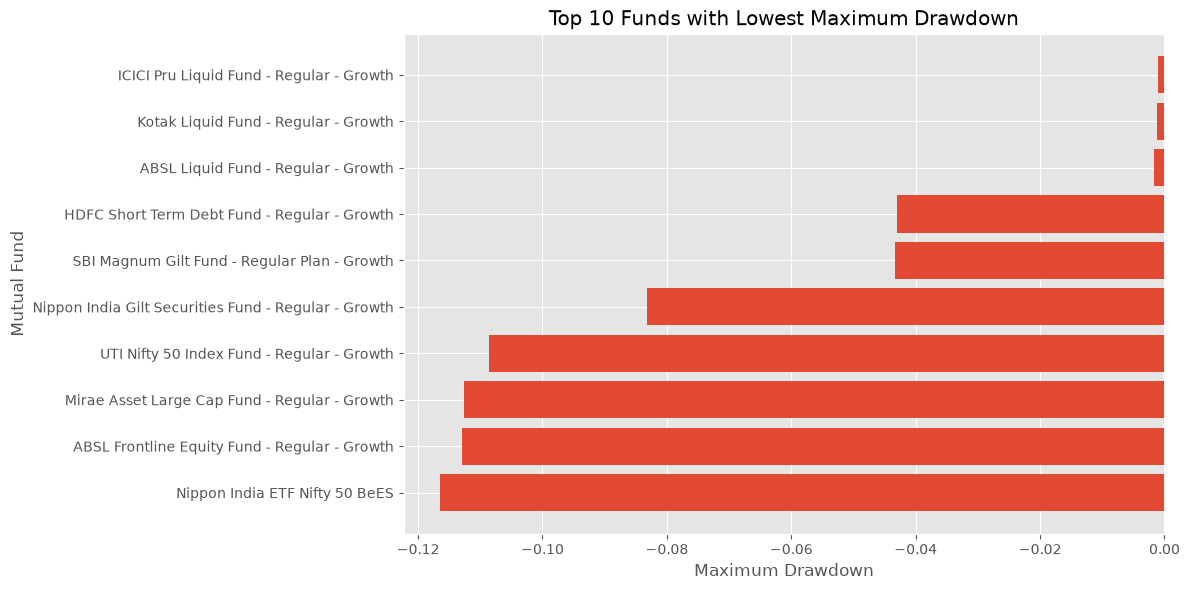

In [157]:
plt.figure(figsize=(12,6))

plt.barh(
    top_drawdown["scheme_name"],
    top_drawdown["calculated_max_drawdown"]
)

plt.xlabel("Maximum Drawdown")
plt.ylabel("Mutual Fund")
plt.title("Top 10 Funds with Lowest Maximum Drawdown")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../reports/performance/04_lowest_max_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

Maximum Drawdown analysis measures the largest decline from a fund's historical peak NAV, highlighting downside risk during adverse market conditions. Funds with smaller drawdowns demonstrated stronger capital preservation, while deeper drawdowns indicate higher volatility and greater recovery requirements. This metric complements return-based measures by evaluating how effectively each scheme managed market downturns.

## 10. Fund Scorecard

In [158]:
performance["rank_return"] = performance["return_3yr_pct"].rank(
    ascending=False,
    method="dense"
)

performance["rank_sharpe"] = performance["calculated_sharpe_ratio"].rank(
    ascending=False,
    method="dense"
)

performance["rank_alpha"] = performance["alpha"].rank(
    ascending=False,
    method="dense"
)

In [159]:
performance["rank_expense"] = performance["expense_ratio_pct"].rank(
    ascending=True,
    method="dense"
)

performance["rank_drawdown"] = performance["calculated_max_drawdown"].rank(
    ascending=False,
    method="dense"
)

In [160]:
performance[
    [
        "scheme_name",
        "rank_return",
        "rank_sharpe",
        "rank_alpha",
        "rank_expense",
        "rank_drawdown"
    ]
].head(10)

,scheme_name,rank_return,rank_sharpe,rank_alpha,rank_expense,rank_drawdown
0,SBI Bluechip Fund - Regular Plan - Growth,26.0,4.0,28.0,24.0,17.0
1,SBI Bluechip Fund - Direct Plan - Growth,34.0,12.0,8.0,4.0,11.0
2,SBI Small Cap Fund - Regular Plan - Growth,1.0,14.0,18.0,18.0,36.0
3,SBI Small Cap Fund - Direct Plan - Growth,2.0,32.0,20.0,5.0,40.0
4,SBI Magnum Gilt Fund - Regular Plan - Growth,38.0,37.0,11.0,8.0,5.0
5,HDFC Top 100 Fund - Regular Plan - Growth,16.0,35.0,31.0,25.0,34.0
6,HDFC Top 100 Fund - Direct Plan - Growth,24.0,18.0,20.0,13.0,18.0
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,10.0,7.0,23.0,15.0,20.0
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,14.0,27.0,25.0,9.0,29.0
9,HDFC Short Term Debt Fund - Regular - Growth,36.0,39.0,1.0,2.0,4.0


In [161]:
performance[
    [
        "rank_return",
        "rank_sharpe",
        "rank_alpha",
        "rank_expense",
        "rank_drawdown"
    ]
] = performance[
    [
        "rank_return",
        "rank_sharpe",
        "rank_alpha",
        "rank_expense",
        "rank_drawdown"
    ]
].fillna(
    performance[
        [
            "rank_return",
            "rank_sharpe",
            "rank_alpha",
            "rank_expense",
            "rank_drawdown"
        ]
    ].max()
)

In [162]:
max_rank = performance[
    [
        "rank_return",
        "rank_sharpe",
        "rank_alpha",
        "rank_expense",
        "rank_drawdown"
    ]
].max().max()

performance["fund_score"] = (
    (
        (max_rank - performance["rank_return"] + 1) / max_rank
    ) * 30
    +
    (
        (max_rank - performance["rank_sharpe"] + 1) / max_rank
    ) * 25
    +
    (
        (max_rank - performance["rank_alpha"] + 1) / max_rank
    ) * 20
    +
    (
        (max_rank - performance["rank_expense"] + 1) / max_rank
    ) * 15
    +
    (
        (max_rank - performance["rank_drawdown"] + 1) / max_rank
    ) * 10
)

In [163]:
scorecard = (
    performance[
        [
            "scheme_name",
            "fund_score"
        ]
    ]
    .sort_values(
        "fund_score",
        ascending=False
    )
)

scorecard.head(10)

,scheme_name,fund_score
22,Kotak Flexicap Fund - Regular - Growth,81.125
34,Mirae Asset Large Cap Fund - Regular - Growth,74.625
12,ICICI Pru Midcap Fund - Regular - Growth,68.875
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,68.500
2,SBI Small Cap Fund - Regular Plan - Growth,68.250
26,Axis Midcap Fund - Regular - Growth,64.750
38,DSP Midcap Fund - Regular - Growth,64.250
29,ABSL Small Cap Fund - Regular - Growth,62.625
35,Mirae Asset Emerging Bluechip Fund - Regular -...,61.375
1,SBI Bluechip Fund - Direct Plan - Growth,61.250


In [164]:
scorecard.describe()

,fund_score
count,40.000000
mean,53.753125
std,11.070161
min,33.500000
25%,45.843750
50%,53.750000
75%,60.781250
max,81.125000


In [165]:
scorecard.to_csv(
    "../reports/performance/fund_scorecard.csv",
    index=False
)

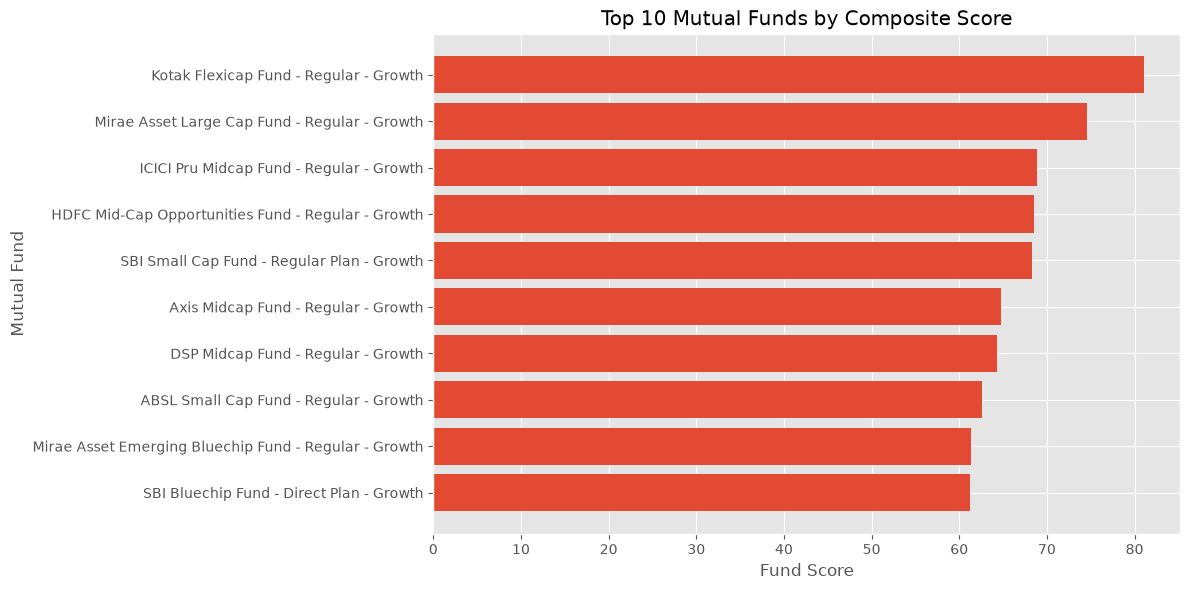

In [166]:
top_score = scorecard.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_score["scheme_name"],
    top_score["fund_score"],
)

plt.xlabel("Fund Score")
plt.ylabel("Mutual Fund")
plt.title("Top 10 Mutual Funds by Composite Score")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../reports/performance/05_fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The composite Fund Score combines long-term returns, risk-adjusted performance, alpha generation, expense efficiency, and downside risk into a single metric. Funds with consistently strong returns, higher Sharpe ratios, positive alpha, lower expenses, and smaller drawdowns achieved the highest overall scores, providing a balanced ranking beyond return performance alone.

## 11. Benchmark Comparison

### Load Benchmark Data

In [167]:
benchmark = pd.read_csv("../data/processed/clean_10_benchmark_indices.csv")
benchmark.head()
benchmark.info()

<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   str    
 1   index_name   8050 non-null   str    
 2   close_value  8050 non-null   float64
dtypes: float64(1), str(2)
memory usage: 188.8 KB


In [168]:
benchmark = pd.read_csv(
    "../data/processed/clean_10_benchmark_indices.csv"
)

In [169]:
benchmark.head()

benchmark.info()

benchmark.describe()

<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   str    
 1   index_name   8050 non-null   str    
 2   close_value  8050 non-null   float64
dtypes: float64(1), str(2)
memory usage: 188.8 KB


,close_value
count,8050.000000
mean,18351.950181
std,14169.995121
min,1444.130000
25%,2819.062500
50%,18392.960000
75%,26539.097500
max,79075.390000


In [170]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

nav["date"] = pd.to_datetime(
    nav["date"]
)

benchmark_names = [
    "NIFTY50",
    "NIFTY100"
]

benchmark = benchmark[
    benchmark["index_name"].isin(benchmark_names)
].copy()

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [171]:
benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark
    .groupby("index_name")["close_value"]
    .pct_change()
)

benchmark.head(10)

benchmark["benchmark_return"].describe()

count    2298.000000
mean        0.000102
std         0.008111
min        -0.026873
25%        -0.005320
50%        -0.000167
75%         0.005669
max         0.026795
Name: benchmark_return, dtype: float64

In [172]:
top5_funds = (
    scorecard
    .head(5)["scheme_name"]
    .tolist()
)

top5_funds

['Kotak Flexicap Fund - Regular - Growth',
 'Mirae Asset Large Cap Fund - Regular - Growth',
 'ICICI Pru Midcap Fund - Regular - Growth',
 'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
 'SBI Small Cap Fund - Regular Plan - Growth']

In [173]:
fund_master = pd.read_csv(
    "../data/processed/clean_01_fund_master.csv"
)

fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [174]:
fund_returns = (
    nav.merge(
        fund_master[
            ["amfi_code", "scheme_name"]
        ],
        on="amfi_code",
        how="left"
    )
)

fund_returns = fund_returns[
    fund_returns["scheme_name"].isin(top5_funds)
].copy()

fund_returns.head()

,amfi_code,date,nav,daily_return,running_peak,drawdown,scheme_name
2300,100033,2022-01-03,107.3758,NaN,107.3758,0.000000,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2301,100033,2022-01-04,105.9447,-0.013328,107.3758,-0.013328,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2302,100033,2022-01-05,105.4800,-0.004386,107.3758,-0.017656,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2303,100033,2022-01-06,104.9350,-0.005167,107.3758,-0.022731,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2304,100033,2022-01-07,104.3318,-0.005748,107.3758,-0.028349,HDFC Mid-Cap Opportunities Fund - Regular - Gr...


In [175]:
comparison = fund_returns.merge(
    benchmark[
        [
            "date",
            "index_name",
            "benchmark_return"
        ]
    ],
    on="date",
    how="inner"
)

comparison.head()

comparison.info()

<class 'pandas.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   amfi_code         11500 non-null  int64         
 1   date              11500 non-null  datetime64[us]
 2   nav               11500 non-null  float64       
 3   daily_return      11490 non-null  float64       
 4   running_peak      11500 non-null  float64       
 5   drawdown          11500 non-null  float64       
 6   scheme_name       11500 non-null  str           
 7   index_name        11500 non-null  str           
 8   benchmark_return  11490 non-null  float64       
dtypes: datetime64[us](1), float64(5), int64(1), str(2)
memory usage: 808.7 KB


In [176]:
tracking_error = (
    comparison
    .groupby(
        ["scheme_name", "index_name"]
    )
    .apply(
        lambda x: (
            (
                x["daily_return"]
                -
                x["benchmark_return"]
            )
            .std()
            *
            np.sqrt(252)
        )
    )
    .reset_index(
        name="tracking_error"
    )
)

tracking_error

,scheme_name,index_name,tracking_error
0,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY100,0.228699
1,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY50,0.229755
2,ICICI Pru Midcap Fund - Regular - Growth,NIFTY100,0.231968
3,ICICI Pru Midcap Fund - Regular - Growth,NIFTY50,0.233124
4,Kotak Flexicap Fund - Regular - Growth,NIFTY100,0.206425
5,Kotak Flexicap Fund - Regular - Growth,NIFTY50,0.205148
6,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY100,0.189664
7,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY50,0.193996
8,SBI Small Cap Fund - Regular Plan - Growth,NIFTY100,0.283881
9,SBI Small Cap Fund - Regular Plan - Growth,NIFTY50,0.278033


In [177]:
comparison_chart = (
    fund_returns[
        [
            "date",
            "scheme_name",
            "nav"
        ]
    ]
    .copy()
)

comparison_chart["normalized_nav"] = (
    comparison_chart
    .groupby("scheme_name")["nav"]
    .transform(
        lambda x:
        x / x.iloc[0] * 100
    )
)

benchmark_chart = (
    benchmark[
        [
            "date",
            "index_name",
            "close_value"
        ]
    ]
    .copy()
)

benchmark_chart["normalized_value"] = (
    benchmark_chart
    .groupby("index_name")["close_value"]
    .transform(
        lambda x:
        x / x.iloc[0] * 100
    )
)

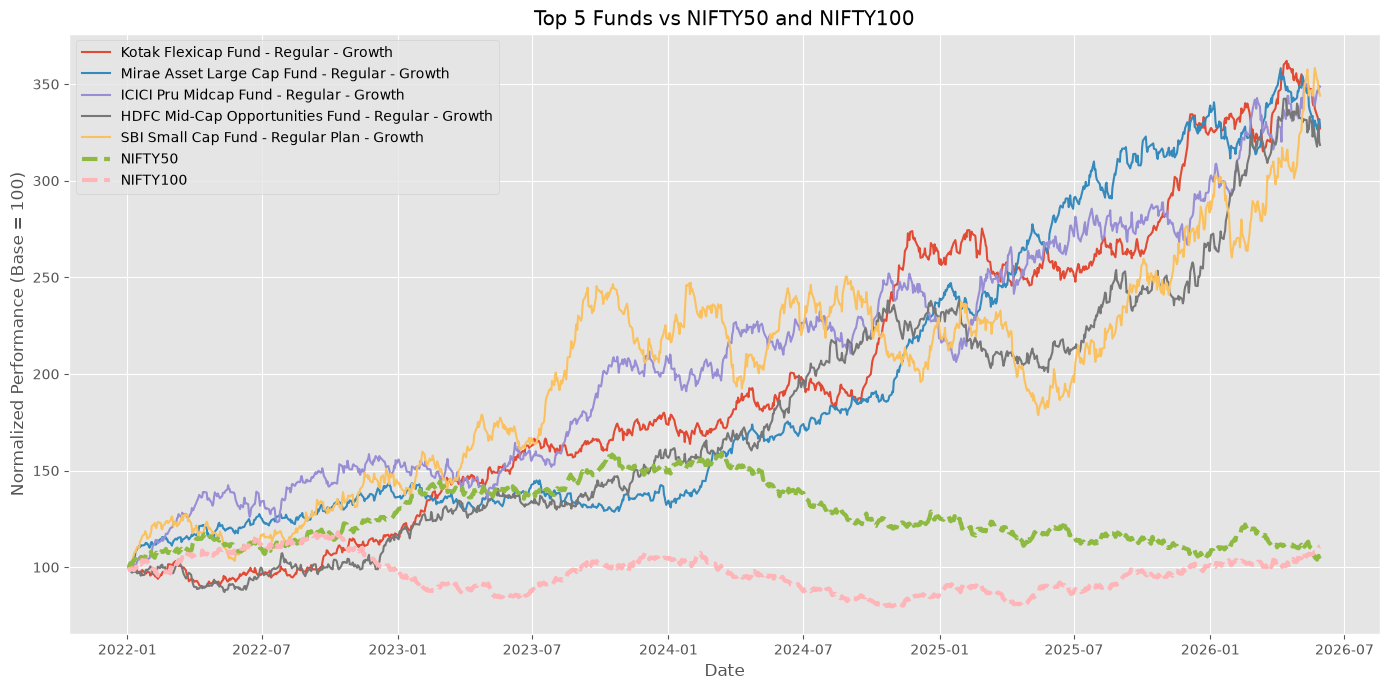

In [178]:
plt.figure(figsize=(14, 7))

for fund in top5_funds:
    temp = comparison_chart[
        comparison_chart["scheme_name"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["normalized_nav"],
        label=fund
    )

for benchmark_name in benchmark_names:
    temp = benchmark_chart[
        benchmark_chart["index_name"]
        ==
        benchmark_name
    ]

    plt.plot(
        temp["date"],
        temp["normalized_value"],
        linewidth=3,
        linestyle="--",
        label=benchmark_name
    )

plt.title(
    "Top 5 Funds vs NIFTY50 and NIFTY100"
)

plt.xlabel("Date")

plt.ylabel(
    "Normalized Performance (Base = 100)"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/performance/06_benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [179]:
tracking_error.to_csv(
    "../reports/performance/tracking_error.csv",
    index=False
)

print("Tracking error saved successfully.")

Tracking error saved successfully.


### Insights

- The five highest-ranked mutual funds were benchmarked against NIFTY50 and NIFTY100 using normalized cumulative performance.
- Daily benchmark returns were calculated from benchmark index closing values and aligned with fund return dates.
- Tracking error was computed as the annualized standard deviation of excess returns relative to each benchmark.
- Lower tracking error indicates closer benchmark replication, while higher values suggest more active portfolio management.
- The comparison chart provides a visual assessment of how consistently the selected funds outperformed or underperformed the market benchmarks over the analysis period.